# Deep Q-Network (DQN) for Turbofan Predictive Maintenance

## Approach

A **proper RL environment** steps through each engine's life cycle. A DQN agent learns via epsilon-greedy exploration, experience replay, and Double DQN targets — not by cloning labels.

| RL concept | Turbofan mapping |
|---|---|
| State `s` | 14-dim normalised rolling-average sensor vector |
| Action `a` | 0 = *continue*, 1 = *flag for maintenance* |
| Reward `r` | Shaped: miss near-failure = −10, false alarm = −3 |
| Episode | One engine's life, stepped cycle-by-cycle until the final cycle |
| Done | `True` on the engine's last recorded cycle |

### Why the previous version was wrong
The old code hard-coded actions from RUL labels (`a = int(rul <= 30)`) then trained on those transitions.  
That is **supervised learning / behavioural cloning**, not RL — the network just memorised the threshold rule.  
Here the agent genuinely explores (ε-greedy), collects its own transitions via environment rollouts,  
and learns entirely from reward signals.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import deque
import random
import copy

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim

sns.set_theme(style='darkgrid')
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

DATA_DIR = Path('../data/CMaps')

INDEX_COLS   = ['unit', 'cycle']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_COLS  = [f's_{i}' for i in range(1, 22)]
ALL_COLS     = INDEX_COLS + SETTING_COLS + SENSOR_COLS
DEAD_SENSORS = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
LIVE_SENSORS = [s for s in SENSOR_COLS if s not in DEAD_SENSORS]

STATE_DIM      = len(LIVE_SENSORS)   # 14
N_ACTIONS      = 2                   # 0=continue, 1=flag
RUL_CAP        = 125
W              = 30                  # rolling-mean window
FLAG_THRESHOLD = 30

# -- DQN hyperparameters -----------------------------------------------------
LR             = 1e-3
GAMMA          = 0.97
BATCH_SIZE     = 256
BUFFER_SIZE    = 50_000
N_EPISODES     = 250       # allow longer training, early stopping will cut it
EPS_START      = 1.0
EPS_END        = 0.05
EPS_DECAY      = 0.98      # slower decay keeps exploration longer
HIDDEN         = [128, 64]

# -- anti-overfitting settings ----------------------------------------------
TRAIN_VAL_RATIO = 0.8      # split by engine id (no leakage across cycles)
DROPOUT         = 0.10
WEIGHT_DECAY    = 1e-5
TAU             = 0.01     # soft target update
EVAL_EVERY      = 5        # evaluate on holdout engines every k episodes
PATIENCE        = 8        # early stopping patience (in eval checkpoints)
MIN_DELTA       = 0.5      # minimum validation-return improvement

print(f'State dim : {STATE_DIM}')
print(f'N actions : {N_ACTIONS}')

Device: cpu
State dim : 14
N actions : 2


## 1. Data Loading & Preprocessing

In [14]:
def load_train(fd_id: int) -> pd.DataFrame:
    df = pd.read_csv(DATA_DIR / f'train_FD00{fd_id}.txt',
                     sep=r'\s+', header=None, names=ALL_COLS, index_col=False)
    max_cycle = df.groupby('unit')['cycle'].max().rename('max_cycle')
    df = df.merge(max_cycle, on='unit')
    df['RUL'] = (df['max_cycle'] - df['cycle']).clip(upper=RUL_CAP).astype(float)
    df.drop(columns='max_cycle', inplace=True)
    return df


def load_test(fd_id: int) -> pd.DataFrame:
    test = pd.read_csv(DATA_DIR / f'test_FD00{fd_id}.txt',
                       sep=r'\s+', header=None, names=ALL_COLS, index_col=False)
    rul_gt = pd.read_csv(DATA_DIR / f'RUL_FD00{fd_id}.txt',
                         sep=r'\s+', header=None, names=['RUL_end'], index_col=False)
    last_cycles = test.groupby('unit')['cycle'].max().rename('last_cycle')
    test = test.merge(last_cycles, on='unit')
    test['is_last'] = test['cycle'] == test['last_cycle']
    unit_ids = sorted(test['unit'].unique())
    rul_map  = dict(zip(unit_ids, rul_gt['RUL_end'].values))
    test['true_RUL'] = test.apply(
        lambda r: float(rul_map[r['unit']] + (r['last_cycle'] - r['cycle'])), axis=1
    ).clip(upper=RUL_CAP)
    return test


def preprocess(df: pd.DataFrame, scaler: MinMaxScaler, fit: bool = False) -> pd.DataFrame:
    df = df.copy()
    for s in LIVE_SENSORS:
        df[s] = (df.groupby('unit')[s]
                   .transform(lambda x: x.rolling(W, min_periods=1).mean()))
    if fit:
        df[LIVE_SENSORS] = scaler.fit_transform(df[LIVE_SENSORS])
    else:
        df[LIVE_SENSORS] = scaler.transform(df[LIVE_SENSORS])
    return df


scaler = MinMaxScaler()
train_raw = preprocess(load_train(1), scaler, fit=True)
print('Train shape:', train_raw.shape)
train_raw.head(3)

Train shape: (20631, 27)


,unit,cycle,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,0.170063,0.562519,0.335837,14.62,...,0.256898,0.218018,0.488517,0.03,0.32967,2388,100.0,0.737937,0.740470,125.0
1,1,2,0.0019,-0.0003,100.0,518.67,0.245902,0.598267,0.368100,14.62,...,0.328259,0.191440,0.522199,0.03,0.32967,2388,100.0,0.700499,0.745620,125.0
2,1,3,-0.0043,0.0003,100.0,518.67,0.301823,0.567128,0.387830,14.62,...,0.313987,0.186905,0.507868,0.03,0.21978,2388,100.0,0.667221,0.688071,125.0


## 2. Turbofan RL Environment

`TurbofanEnv` wraps the CMAPSS dataset as a proper gym-style environment:
- `reset()` picks a random engine and returns its first observation
- `step(action)` advances one cycle, computes the reward, and signals `done` at the final cycle

The agent never sees RUL directly — it only receives sensor readings and the reward signal.

In [15]:
class TurbofanEnv:
    """
    Gym-style environment over a preprocessed CMAPSS DataFrame.

    Observation : 14-dim normalised sensor vector  (agent does NOT see RUL)
    Action      : 0 = continue, 1 = flag for maintenance
    Reward      : shaped by proximity to failure (FLAG_THRESHOLD)
    Episode     : one engine life from cycle 0 -> final cycle
    """

    def __init__(self, df: pd.DataFrame, unit_ids=None):
        # Store episodes as numpy arrays keyed by unit id
        self.episodes = {}
        for uid, grp in df.groupby('unit'):
            ep = grp[LIVE_SENSORS + ['RUL']].reset_index(drop=True)
            self.episodes[uid] = ep

        all_unit_ids = list(self.episodes.keys())
        if unit_ids is None:
            self.unit_ids = all_unit_ids
        else:
            allowed = set(unit_ids)
            self.unit_ids = [u for u in all_unit_ids if u in allowed]

        if len(self.unit_ids) == 0:
            raise ValueError('TurbofanEnv needs at least one unit id.')

        self._ep   = None
        self._step = 0

    # -- core interface -------------------------------------------------------

    def reset(self, uid=None) -> np.ndarray:
        if uid is None:
            uid = random.choice(self.unit_ids)
        self._ep   = self.episodes[uid]
        self._step = 0
        return self._obs()

    def step(self, action: int):
        rul  = float(self._ep.loc[self._step, 'RUL'])
        r    = self._reward(action, rul)
        done = self._step == len(self._ep) - 2
        self._step += 1
        obs  = self._obs()
        return obs, r, done, {'rul': rul}

    def __len__(self):
        return len(self.unit_ids)

    # -- internal helpers ----------------------------------------------------

    def _obs(self) -> np.ndarray:
        return self._ep.loc[self._step, LIVE_SENSORS].values.astype(np.float32)

    @staticmethod
    def _reward(action: int, rul: float) -> float:
        near = rul <= FLAG_THRESHOLD
        if action == 0 and not near: return  1.0   # correct: keep running
        if action == 0 and near:     return -10.0  # missed near-failure
        if action == 1 and not near: return -3.0   # false alarm
        return  5.0                                 # correct: flag before failure


env = TurbofanEnv(train_raw)
print(f'Engines in env : {len(env)}')

# Sanity check -- single rollout
obs = env.reset()
print(f'Initial obs shape : {obs.shape}')
obs, r, done, info = env.step(0)
print(f'After step  -> reward={r}, done={done}, rul={info["rul"]:.1f}')

Engines in env : 100
Initial obs shape : (14,)
After step  -> reward=1.0, done=False, rul=125.0


## 3. Replay Buffer

A fixed-size `deque` stores `(s, a, r, s', done)` transitions.  
Random mini-batch sampling breaks temporal correlations that would destabilise training.

In [16]:
class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s_next, done):
        self.buf.append((s, a, r, s_next, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s_next, done = zip(*batch)
        return (
            torch.tensor(np.array(s),      dtype=torch.float32).to(DEVICE),
            torch.tensor(a,                dtype=torch.long).to(DEVICE),
            torch.tensor(r,                dtype=torch.float32).to(DEVICE),
            torch.tensor(np.array(s_next), dtype=torch.float32).to(DEVICE),
            torch.tensor(done,             dtype=torch.float32).to(DEVICE),
        )

    def __len__(self):
        return len(self.buf)


print('ReplayBuffer defined.')

ReplayBuffer defined.


## 4. DQN Network Architecture

Dueling head separates **state value** V(s) from **advantage** A(s,a):

```
Q(s,a) = V(s) + A(s,a) − mean(A(s,·))
```

This stabilises training: the network can learn how good a state is independently of which action to pick.

In [17]:
class DuelingDQN(nn.Module):
    """
    Dueling Double DQN.
    Shared encoder -> separate value and advantage streams.
    Q(s,a) = V(s) + A(s,a) - mean_a(A(s,.))
    """

    def __init__(self, state_dim: int, n_actions: int, hidden: list, dropout: float = DROPOUT):
        super().__init__()

        # Shared feature extractor
        layers = []
        in_dim = state_dim
        for h in hidden:
            layers += [
                nn.Linear(in_dim, h),
                nn.LayerNorm(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        self.encoder = nn.Sequential(*layers)

        # Value stream: scalar V(s)
        self.value_head = nn.Linear(in_dim, 1)

        # Advantage stream: A(s,a) per action
        self.adv_head = nn.Linear(in_dim, n_actions)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.encoder(x)
        v    = self.value_head(feat)                    # (B, 1)
        a    = self.adv_head(feat)                      # (B, n_actions)
        # Combine - subtract mean advantage to keep Q identifiable
        return v + a - a.mean(dim=1, keepdim=True)


def make_networks():
    online = DuelingDQN(STATE_DIM, N_ACTIONS, HIDDEN, dropout=DROPOUT).to(DEVICE)
    target = DuelingDQN(STATE_DIM, N_ACTIONS, HIDDEN, dropout=DROPOUT).to(DEVICE)
    target.load_state_dict(online.state_dict())
    target.eval()
    return online, target


online_net, target_net = make_networks()
total_params = sum(p.numel() for p in online_net.parameters())
print(online_net)
print(f'\nParameters: {total_params:,}')

DuelingDQN(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
  )
  (value_head): Linear(in_features=64, out_features=1, bias=True)
  (adv_head): Linear(in_features=64, out_features=2, bias=True)
)

Parameters: 10,755


## 5. Training Loop — Dueling Double DQN with epsilon-Greedy Exploration

> Anti-overfitting updates added while keeping DQN:
- Validation split by engine id (holdout engines never seen in training episodes)
- Early stopping on validation return
- Light regularization (dropout + Adam weight decay)
- Soft target updates (`tau`) instead of hard periodic copies

Each episode:
1. Reset to a random engine from the training split
2. At every cycle: pick action epsilon-greedy (random with prob epsilon, greedy otherwise)
3. Store `(s, a, r, s', done)` in the replay buffer
4. Once buffer has >= `BATCH_SIZE` transitions, sample a mini-batch and do a gradient step
5. Periodically evaluate on holdout engines and stop early if validation no longer improves

In [18]:
def split_units(df: pd.DataFrame, ratio: float = TRAIN_VAL_RATIO, seed: int = 42):
    unit_ids = np.array(sorted(df['unit'].unique()))
    rng = np.random.default_rng(seed)
    rng.shuffle(unit_ids)
    n_train = max(1, int(len(unit_ids) * ratio))
    train_units = unit_ids[:n_train].tolist()
    val_units   = unit_ids[n_train:].tolist()
    if len(val_units) == 0:
        val_units = train_units[-1:]
        train_units = train_units[:-1]
    return train_units, val_units


def greedy_rollout_return(env: TurbofanEnv, model: nn.Module, uid: int) -> float:
    model.eval()
    obs = env.reset(uid=uid)
    done = False
    total = 0.0
    while not done:
        with torch.no_grad():
            q = model(torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(DEVICE))
            action = int(q.argmax(dim=1).item())
        obs, reward, done, _ = env.step(action)
        total += reward
    return float(total)


def train_dqn(df: pd.DataFrame, n_episodes: int = N_EPISODES):
    train_units, val_units = split_units(df, ratio=TRAIN_VAL_RATIO, seed=42)
    env_train = TurbofanEnv(df, unit_ids=train_units)
    env_val   = TurbofanEnv(df, unit_ids=val_units)

    online, target = make_networks()
    optimizer = optim.Adam(online.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn   = nn.HuberLoss()
    buffer    = ReplayBuffer(BUFFER_SIZE)

    eps = EPS_START
    episode_returns = []
    losses = []
    val_returns = []

    best_val = -np.inf
    best_state = copy.deepcopy(online.state_dict())
    no_improve = 0

    for ep in range(1, n_episodes + 1):
        online.train()
        obs  = env_train.reset()
        done = False
        ep_return = 0.0

        while not done:
            # epsilon-greedy action selection
            if random.random() < eps:
                action = random.randint(0, N_ACTIONS - 1)
            else:
                with torch.no_grad():
                    q = online(torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(DEVICE))
                    action = int(q.argmax(dim=1).item())

            obs_next, reward, done, _ = env_train.step(action)
            buffer.push(obs, action, reward, obs_next, float(done))
            obs        = obs_next
            ep_return += reward

            # Learn when buffer is warm
            if len(buffer) >= BATCH_SIZE:
                s_b, a_b, r_b, sn_b, done_b = buffer.sample(BATCH_SIZE)

                # Current Q for taken actions
                q_vals = online(s_b).gather(1, a_b.unsqueeze(1)).squeeze(1)

                # Double DQN target: online selects, target evaluates
                with torch.no_grad():
                    best_a  = online(sn_b).argmax(dim=1, keepdim=True)
                    q_next  = target(sn_b).gather(1, best_a).squeeze(1)
                    targets = r_b + GAMMA * q_next * (1.0 - done_b)

                loss = loss_fn(q_vals, targets)
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(online.parameters(), 1.0)
                optimizer.step()
                losses.append(loss.item())

                # Soft target update
                with torch.no_grad():
                    for t_param, o_param in zip(target.parameters(), online.parameters()):
                        t_param.data.mul_(1.0 - TAU).add_(TAU * o_param.data)

        episode_returns.append(ep_return)
        eps = max(EPS_END, eps * EPS_DECAY)

        # Periodic validation on holdout engines + early stopping
        if ep % EVAL_EVERY == 0:
            vret = np.mean([greedy_rollout_return(env_val, online, uid) for uid in env_val.unit_ids])
            val_returns.append(vret)

            if vret > best_val + MIN_DELTA:
                best_val = vret
                best_state = copy.deepcopy(online.state_dict())
                no_improve = 0
            else:
                no_improve += 1

            if no_improve >= PATIENCE:
                print(f'Early stopping at episode {ep} (best val_return={best_val:.1f})')
                break

        if ep % 20 == 0 or ep == 1:
            avg_ret  = np.mean(episode_returns[-20:])
            avg_loss = np.mean(losses[-100:]) if losses else float('nan')
            last_val = val_returns[-1] if val_returns else float('nan')
            print(f'Episode {ep:4d}/{n_episodes}  eps={eps:.3f}  '
                  f'avg_return={avg_ret:7.1f}  val_return={last_val:7.1f}  '
                  f'loss={avg_loss:.4f}  buffer={len(buffer):,}')

    # Restore best checkpoint by validation return
    online.load_state_dict(best_state)
    online.eval()
    return online, episode_returns, losses, val_returns


online_net, ep_returns, train_losses, val_returns = train_dqn(train_raw)

Episode    1/250  eps=0.980  avg_return= -151.0  val_return=    nan  loss=nan  buffer=201
Episode   20/250  eps=0.668  avg_return= -148.6  val_return=  157.2  loss=2.1133  buffer=3,853
Episode   40/250  eps=0.446  avg_return=  -62.1  val_return=  238.3  loss=2.3348  buffer=8,154
Episode   60/250  eps=0.298  avg_return=   45.6  val_return=  242.1  loss=2.4406  buffer=12,050
Episode   80/250  eps=0.199  avg_return=  132.4  val_return=  224.2  loss=2.2284  buffer=16,639
Early stopping at episode 100 (best val_return=242.1)


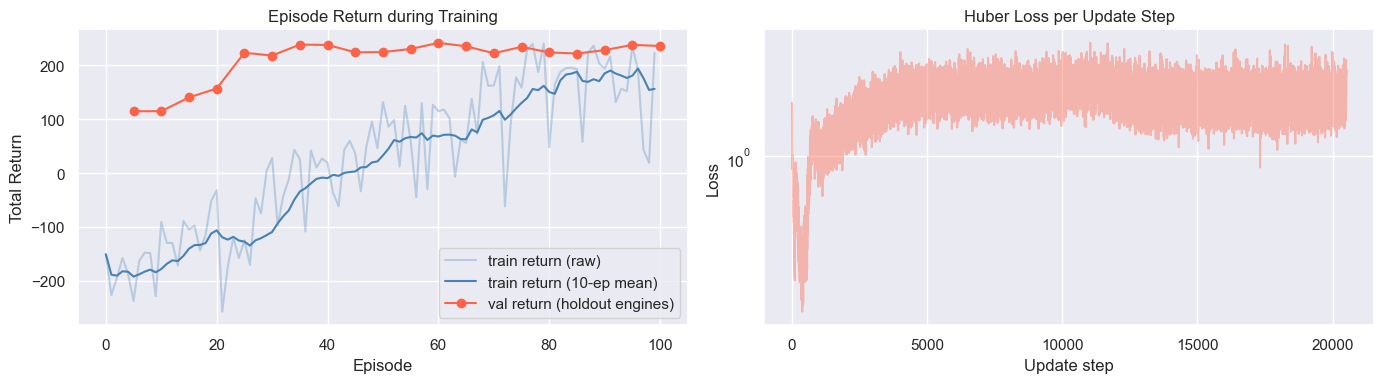

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Episode returns (smoothed)
window = 10
smoothed = pd.Series(ep_returns).rolling(window, min_periods=1).mean()
ax1.plot(ep_returns, alpha=0.3, color='steelblue', label='train return (raw)')
ax1.plot(smoothed,   color='steelblue',            label=f'train return ({window}-ep mean)')

if len(val_returns) > 0:
    val_x = np.arange(EVAL_EVERY, EVAL_EVERY * len(val_returns) + 1, EVAL_EVERY)
    ax1.plot(val_x, val_returns, marker='o', color='tomato', label='val return (holdout engines)')

ax1.set(title='Episode Return during Training', xlabel='Episode', ylabel='Total Return')
ax1.legend()

# Training loss
ax2.plot(train_losses, alpha=0.4, color='tomato')
ax2.set(title='Huber Loss per Update Step', xlabel='Update step', ylabel='Loss')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

## 6. Q-Value Inspection Along a Degradation Trajectory

Plot the learned Q-values and greedy policy for a single engine from the training set.  
We expect Q(flag) to rise and overtake Q(continue) as RUL drops toward the threshold.

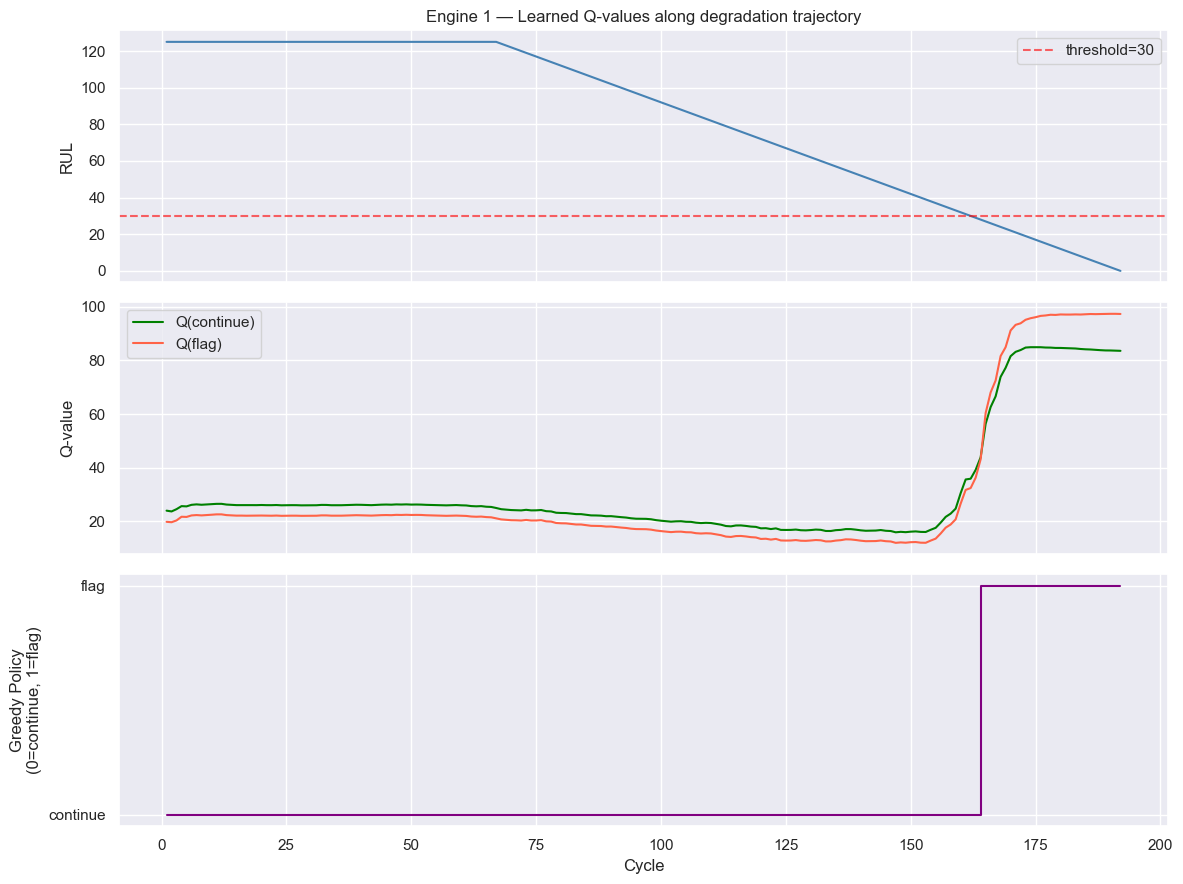

In [20]:
online_net.eval()

engine_id = 1
ep = train_raw[train_raw['unit'] == engine_id][LIVE_SENSORS + ['cycle', 'RUL']].reset_index(drop=True)
states_t = torch.tensor(ep[LIVE_SENSORS].values, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    q_vals_ep = online_net(states_t).cpu().numpy()   # (T, 2)

pred_actions = q_vals_ep.argmax(axis=1)
cycles       = ep['cycle'].values

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(cycles, ep['RUL'].values, color='steelblue')
axes[0].axhline(FLAG_THRESHOLD, color='red', linestyle='--', alpha=0.6, label=f'threshold={FLAG_THRESHOLD}')
axes[0].set_ylabel('RUL')
axes[0].legend()
axes[0].set_title(f'Engine {engine_id} — Learned Q-values along degradation trajectory')

axes[1].plot(cycles, q_vals_ep[:, 0], label='Q(continue)', color='green')
axes[1].plot(cycles, q_vals_ep[:, 1], label='Q(flag)',     color='tomato')
axes[1].set_ylabel('Q-value')
axes[1].legend()

axes[2].step(cycles, pred_actions, color='purple', linewidth=1.5)
axes[2].set_ylabel('Greedy Policy\n(0=continue, 1=flag)')
axes[2].set_xlabel('Cycle')
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['continue', 'flag'])

plt.tight_layout()
plt.show()

## 7. Evaluation on Test Set

For each test unit we run the greedy policy over **all** cycles, then take the **majority vote over the last 15 cycles** as the final prediction.  
Ground truth: `flag` if the published RUL at the last observed cycle ≤ 30.


FD001  accuracy=0.890  n_units=100
              precision    recall  f1-score   support

    continue       0.89      0.97      0.93        75
        flag       0.89      0.64      0.74        25

    accuracy                           0.89       100
   macro avg       0.89      0.81      0.84       100
weighted avg       0.89      0.89      0.88       100



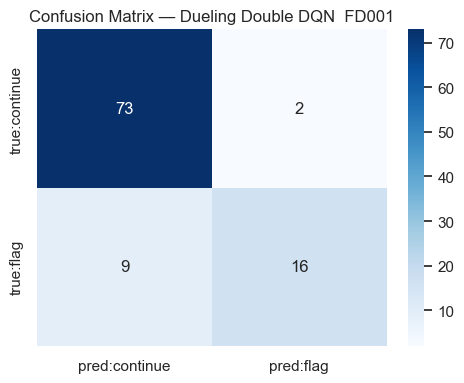

In [21]:
VOTE_WINDOW = 15

def evaluate(model: nn.Module, sc: MinMaxScaler, fd_id: int,
             vote_window: int = VOTE_WINDOW, verbose: bool = True):
    model.eval()
    test = preprocess(load_test(fd_id), sc, fit=False)
    states_t = torch.tensor(test[LIVE_SENSORS].values, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        test['pred_action'] = model(states_t).cpu().numpy().argmax(axis=1)

    results = []
    for uid, grp in test.groupby('unit'):
        vote     = int(grp.tail(vote_window)['pred_action'].mode()[0])
        true_rul = float(grp[grp['is_last']]['true_RUL'].iloc[0])
        true_act = int(true_rul <= FLAG_THRESHOLD)
        results.append({'unit': uid, 'pred': vote, 'true': true_act, 'true_RUL': true_rul})

    res_df = pd.DataFrame(results)
    acc    = (res_df['pred'] == res_df['true']).mean()

    if verbose:
        print(f'\nFD00{fd_id}  accuracy={acc:.3f}  n_units={len(res_df)}')
        print(classification_report(res_df['true'], res_df['pred'],
                                    target_names=['continue', 'flag'], zero_division=0))
        cm = confusion_matrix(res_df['true'], res_df['pred'])
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['pred:continue', 'pred:flag'],
                    yticklabels=['true:continue', 'true:flag'])
        ax.set_title(f'Confusion Matrix — Dueling Double DQN  FD00{fd_id}')
        plt.tight_layout()
        plt.show()

    return acc, res_df


acc_fd1, res_fd1 = evaluate(online_net, scaler, fd_id=1)

## 8. All-Dataset Benchmark (FD001–FD004)

Train a fresh agent on each dataset and compare accuracy against baselines.


========================================  FD001  ========================================
Episode    1/250  eps=0.980  avg_return= -288.0  val_return=    nan  loss=nan  buffer=199
Episode   20/250  eps=0.668  avg_return= -172.5  val_return=  228.3  loss=1.6228  buffer=4,403
Episode   40/250  eps=0.446  avg_return=  -27.8  val_return=  248.3  loss=1.9819  buffer=8,738
Episode   60/250  eps=0.298  avg_return=   13.2  val_return=  254.2  loss=2.0133  buffer=12,712
Episode   80/250  eps=0.199  avg_return=   93.3  val_return=  249.3  loss=2.0651  buffer=16,999
Early stopping at episode 100 (best val_return=254.2)
  -> accuracy = 0.880

========================================  FD002  ========================================
Episode    1/250  eps=0.980  avg_return= -230.0  val_return=    nan  loss=nan  buffer=177
Episode   20/250  eps=0.668  avg_return= -187.6  val_return=  198.8  loss=2.4303  buffer=4,351
Episode   40/250  eps=0.446  avg_return=  -60.1  val_return=  199.1  loss=2.9099  buf

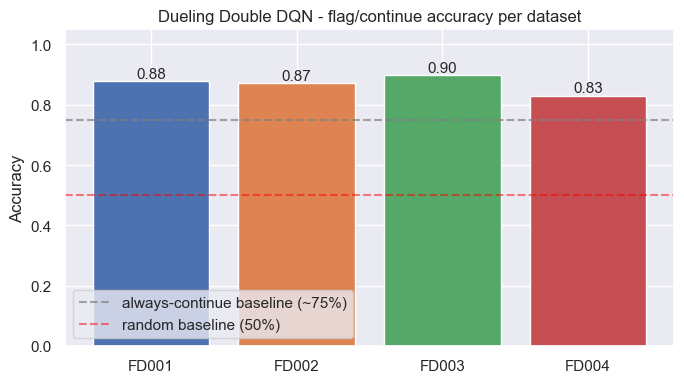

dataset  accuracy
  FD001  0.880000
  FD002  0.872587
  FD003  0.900000
  FD004  0.830645


In [22]:
benchmark = []

for fd_id in range(1, 5):
    print(f'\n{"="*40}  FD00{fd_id}  {"="*40}')
    sc  = MinMaxScaler()
    tr  = preprocess(load_train(fd_id), sc, fit=True)
    model, _, _, _ = train_dqn(tr)
    acc, _ = evaluate(model, sc, fd_id, verbose=False)
    benchmark.append({'dataset': f'FD00{fd_id}', 'accuracy': acc})
    print(f'  -> accuracy = {acc:.3f}')

bdf = pd.DataFrame(benchmark)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(bdf['dataset'], bdf['accuracy'], color=sns.color_palette()[:4])
ax.axhline(0.75, color='grey', linestyle='--', alpha=0.7, label='always-continue baseline (~75%)')
ax.axhline(0.5,  color='red',  linestyle='--', alpha=0.5, label='random baseline (50%)')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Dueling Double DQN - flag/continue accuracy per dataset')
for bar, row in zip(bars, bdf.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{row.accuracy:.2f}', ha='center', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

print(bdf.to_string(index=False))

## 9. Policy Roll-out Visualisation

Apply the greedy policy to 6 test engines. The red zone marks cycles where the agent flags for maintenance. We want the red zone to appear when RUL is near or below the threshold line.

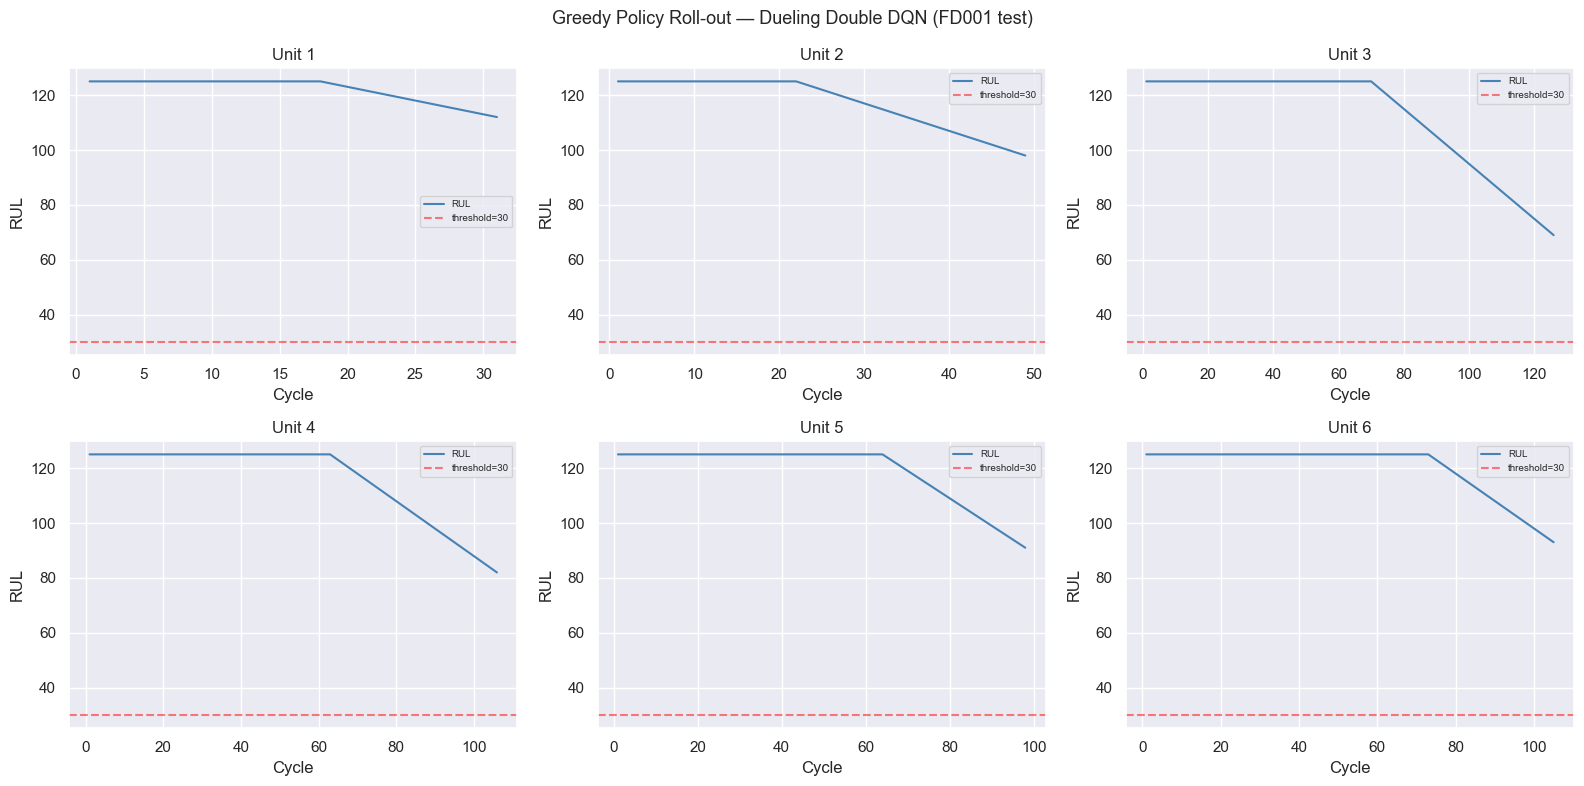

In [23]:
online_net.eval()
test_fd1  = preprocess(load_test(1), scaler, fit=False)
states_t  = torch.tensor(test_fd1[LIVE_SENSORS].values, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    test_fd1['pred_action'] = online_net(states_t).cpu().numpy().argmax(axis=1)

sample_units = test_fd1['unit'].unique()[:6]
fig, axes    = plt.subplots(2, 3, figsize=(16, 8))

for ax, uid in zip(axes.flat, sample_units):
    e = test_fd1[test_fd1['unit'] == uid].reset_index(drop=True)
    ax.plot(e['cycle'], e['true_RUL'], label='RUL', color='steelblue')
    flag_cycles = e[e['pred_action'] == 1]['cycle']
    if len(flag_cycles):
        ax.axvspan(flag_cycles.min(), flag_cycles.max(),
                   alpha=0.25, color='tomato', label='FLAG zone')
    ax.axhline(FLAG_THRESHOLD, color='red', linestyle='--', alpha=0.5,
               label=f'threshold={FLAG_THRESHOLD}')
    ax.set(title=f'Unit {uid}', xlabel='Cycle', ylabel='RUL')
    ax.legend(fontsize=7)

plt.suptitle('Greedy Policy Roll-out — Dueling Double DQN (FD001 test)', fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
import os
os.makedirs('../models', exist_ok=True)
torch.save({
    'model_state':    online_net.state_dict(),
    'scaler':         scaler,
    'hidden':         HIDDEN,
    'state_dim':      STATE_DIM,
    'n_actions':      N_ACTIONS,
    'live_sensors':   LIVE_SENSORS,
    'rul_cap':        RUL_CAP,
    'flag_threshold': FLAG_THRESHOLD,
}, '../models/dueling_ddqn_fd001_theo.pt')
print('Saved → ../models/dueling_ddqn_fd001_theo.pt')

Saved → ../models/dueling_ddqn_fd001_theo.pt
